# 03 · RFM, cohorts and segmentation
RFM quintile cutoffs are fitted on train snapshots only.

In [1]:
import os, pathlib
os.chdir(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd())
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from IPython.display import Image, display
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
from retail_targeting.config import load_config
cfg = load_config()
T = lambda name: pd.read_csv(f"outputs/tables/{name}")

In [2]:
import json; json.load(open('outputs/models/rfm_cutoffs.json'))

{'fit_on': 'split == train',
 'cutoffs': {'r': [14.574444444444445,
   33.48361111111111,
   60.40111111111111,
   102.50722222222223],
  'f': [1.0, 2.0, 4.0],
  'm': [212.25, 383.102, 687.8260000000005, 1364.92]}}

In [3]:
seg = T('rfm_segments.csv'); seg

,split,customer_segment,customers,repeat_rate,median_monetary,median_aov,median_recency
0,test,Developing,1258,0.662957,570.535,261.328571,37.913542
1,test,Dormant,2033,0.403345,263.660,213.950000,112.440972
2,test,High-value active,1204,0.843854,1605.030,382.147083,13.240972
3,test,High-value at risk,464,0.659483,1061.390,547.017500,85.520486
4,test,Low-value active,575,0.424348,187.020,187.020000,33.502778
5,train,Developing,5835,0.537275,581.870,274.390000,36.487500
6,train,Dormant,7620,0.344357,269.920,208.280000,108.433333
7,train,High-value active,5608,0.761234,1612.555,383.005714,13.507292
8,train,High-value at risk,1975,0.528608,1075.590,545.250000,86.298611
9,train,Low-value active,2949,0.292302,204.050,204.050000,30.422917


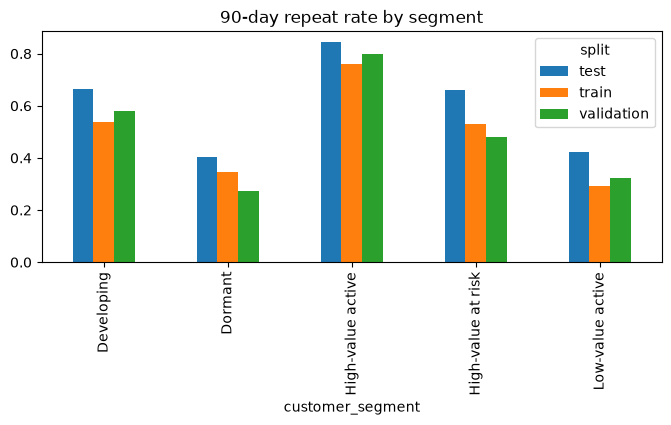

In [4]:
seg.pivot(index='customer_segment', columns='split', values='repeat_rate').plot.bar(figsize=(8,3), title='90-day repeat rate by segment'); plt.show()

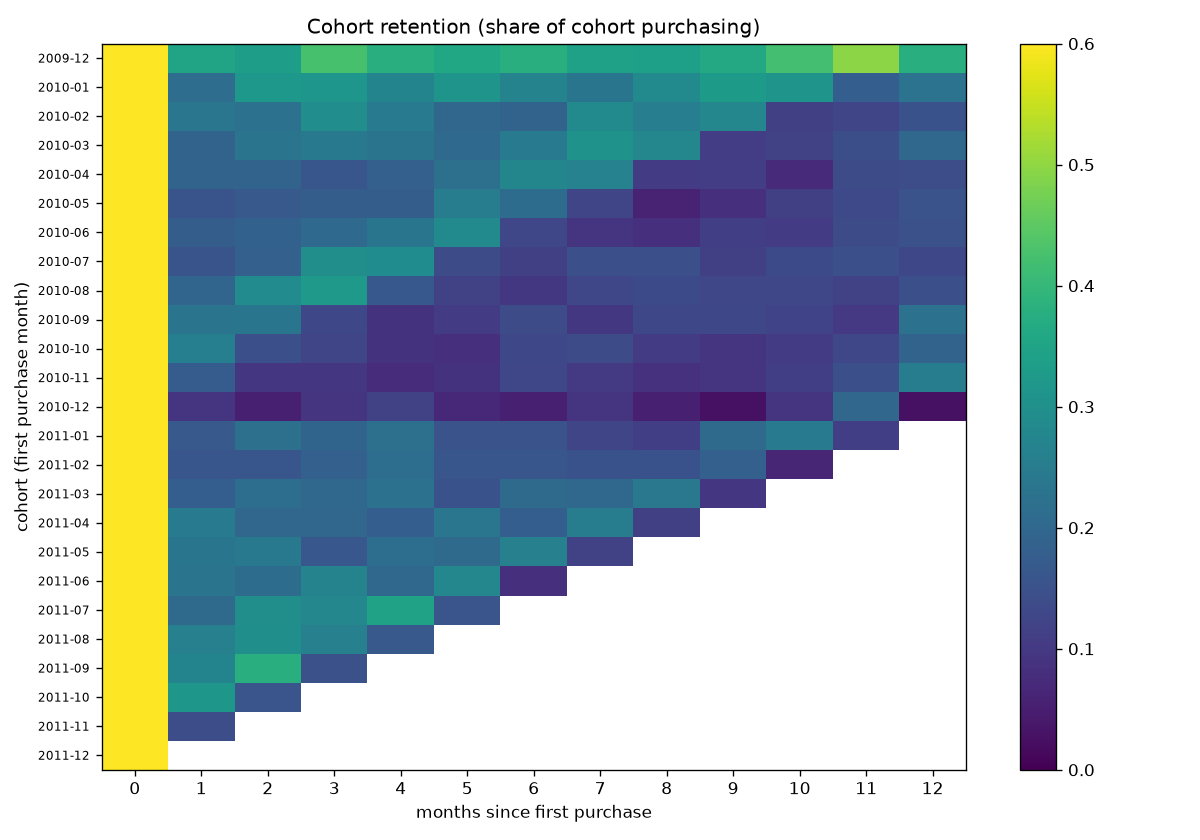

In [5]:
display(Image('outputs/figures/cohort_retention.png'))